## 1. What this notebook computes

The field equations of the theory contain eight real $16 \times 16$ matrices, the
*gamma matrices* $\gamma^{(x_1)}, \gamma^{(x_2)}, \dots, \gamma^{(x_8)}$, one for each
direction $x_1, \dots, x_8$ of the author's 4+4 dimensional space-time. The author
built them in his Mathematica notebook
`Pair_Creation_of_Universes_WaveFunctionOfUniverse-4+4-Einstein-Lovelock-Nash.nb`
from a few small building blocks, and he calls the finished $16 \times 16$ matrices
T16. This notebook repeats his construction step by step, with exact integer
arithmetic, and checks every property that the Revision record checks. It

- builds the six $4 \times 4$ blocks s4[h] and t4[h] (h = 1, 2, 3) from the author's
  formulas and compares them with the six matrices that his notebook displays;
- shows that these blocks are the multiplications of quaternions (a number system
  with four components), which explains their rules;
- builds the $8 \times 8$ matrices sigma, tau[A] and taubar[A] (A = 0, ..., 7) and
  checks their rules;
- assembles the $16 \times 16$ matrices T16[A] (A = 0, ..., 8);
- names them after the author's coordinates: $\gamma^{(x_8)}$ = T16[0] and
  $\gamma^{(x_k)}$ = T16[k] for k = 1, ..., 7;
- checks the Clifford relation
  $\gamma^a \gamma^b + \gamma^b \gamma^a = 2 \eta^{ab} I_{16}$ for all 64 pairs
  $(a, b)$, and that every gamma matrix is real, a signed permutation matrix, and
  symmetric (space-like directions) or antisymmetric (time-like directions);
- compares every entry with the two Revision record files that hold the gammas;
- draws six figures (heat maps).

Every check prints a line that starts with PASS. When the Revision record made the
same check, the lines below the PASS line name the record file and its check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 04a (The author's gamma matrices T16 built from his formulas) is the file
`Revision/textbook/notebooks/04a_t16_from_formulas.ipynb` of the repository Dirac_claude.
It rebuilds, with exact integer arithmetic, the author's eight real 16 by 16 gamma
matrices T16 from his own formulas (the 4 by 4 blocks s4 and t4, the 8 by 8 matrices
sigma, tau and taubar), names them after the author's coordinates x1 to x8, checks the
Clifford relation for all 64 pairs and every other property that the Revision record
checks, compares every entry with the Revision record files, and draws six heat maps. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 04a_t16_from_formulas.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 04a_t16_from_formulas.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
04a_t16_from_formulas.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/04a.captions.json`
- `Revision/textbook/figures/04a_1_blocks_s4_t4.png`
- `Revision/textbook/figures/04a_2_tau_matrices.png`
- `Revision/textbook/figures/04a_3_block_form_of_t16.png`
- `Revision/textbook/figures/04a_4_gammas_x1_to_x8.png`
- `Revision/textbook/figures/04a_5_anticommutator_table.png`
- `Revision/textbook/figures/04a_6_symmetry_pattern.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 28 CHECKS PASSED (notebook 04a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/04a_t16_from_formulas.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 04a_t16_from_formulas.ipynb
      python -m nbconvert --execute --inplace 04a_t16_from_formulas.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `Revision/algebra/gammas.json` or for a file in
  `Revision/algebra/reports`: the notebook reads these Revision record files of the
  repository; they are part of every complete clone. Run `git status` in the repository
  folder: if it reports them as deleted, restore them with the command below and run the
  notebook again.

      git checkout HEAD Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 04a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 04a (The author's gamma matrices T16 built from his formulas) is the file
# Revision/textbook/notebooks/04a_t16_from_formulas.ipynb of the repository Dirac_claude.
# It rebuilds, with exact integer arithmetic, the author's eight real 16 by 16 gamma
# matrices T16 from his own formulas (the 4 by 4 blocks s4 and t4, the 8 by 8 matrices
# sigma, tau and taubar), names them after the author's coordinates x1 to x8, checks the
# Clifford relation for all 64 pairs and every other property that the Revision record
# checks, compares every entry with the Revision record files, and draws six heat maps.
# It needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 04a_t16_from_formulas.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 04a_t16_from_formulas.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 04a_t16_from_formulas.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/04a.captions.json
# - Revision/textbook/figures/04a_1_blocks_s4_t4.png
# - Revision/textbook/figures/04a_2_tau_matrices.png
# - Revision/textbook/figures/04a_3_block_form_of_t16.png
# - Revision/textbook/figures/04a_4_gammas_x1_to_x8.png
# - Revision/textbook/figures/04a_5_anticommutator_table.png
# - Revision/textbook/figures/04a_6_symmetry_pattern.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 28 CHECKS PASSED (notebook 04a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/04a_t16_from_formulas.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 04a_t16_from_formulas.ipynb
#     python -m nbconvert --execute --inplace 04a_t16_from_formulas.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or for a file in
#   Revision/algebra/reports: the notebook reads these Revision record files of the
#   repository; they are part of every complete clone. Run git status in the repository
#   folder: if it reports them as deleted, restore them with the command below and run
#   the notebook again.
#     git checkout HEAD Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "04a"  # this notebook: chapter 04, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 04a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix**: a rectangular table of numbers. An $n \times n$ matrix has $n$ rows
  and $n$ columns; $M_{ij}$ is the *entry* in row $i$ and column $j$. numpy counts
  rows and columns from 0; the author's Mathematica notebook counts them from 1. This
  notebook counts from 0, except in the $4 \times 4$ blocks, whose formulas use the
  author's indices $p, q = 1, \dots, 4$ and $h = 1, 2, 3$.
- **Product of matrices**: $(AB)_{ij} = \sum_k A_{ik} B_{kj}$ (row $i$ of $A$ times
  column $j$ of $B$, entry by entry, added up). In Python it is written `A @ B`. The
  order matters: in general $AB \neq BA$.
- **Identity matrix** $I_n$: 1 on the diagonal, 0 elsewhere; $I_n M = M I_n = M$.
- **Transpose** $M^T$: rows and columns exchanged, $(M^T)_{ij} = M_{ji}$. $M$ is
  **symmetric** if $M^T = M$ and **antisymmetric** if $M^T = -M$.
- **Block matrix**: a big matrix cut into smaller matrices (blocks). For example
  $\begin{pmatrix} 0 & B \\ D & 0 \end{pmatrix}$ has the zero matrix as its upper-left
  and lower-right blocks.
- **Signed permutation matrix**: a matrix with exactly one nonzero entry, $+1$ or
  $-1$, in every row and every column. Acting on a column $u$ it reorders the
  components and flips some signs. We describe row $i$ by a short *code*: the code
  +5 in row 2 means $(Mu)_2 = +u_5$, and -0 means $-u_0$.
- **Permutation sign** (Mathematica's *Signature*): for a list of different numbers,
  $+1$ if the number of *inversions* (pairs of positions in which the larger number
  stands first) is even, $-1$ if it is odd; for a list with a repeated number, 0.
- **Kronecker delta** $\delta_{ij}$: 1 if $i = j$, otherwise 0.
- **Anticommutator** $\{A, B\} = AB + BA$; **commutator** $[A, B] = AB - BA$. Two
  matrices *anticommute* if $\{A, B\} = 0$ and *commute* if $[A, B] = 0$.
- **Frame metric** $\eta$: the diagonal matrix of signs that says which directions
  are space-like ($+1$) and which are time-like ($-1$); here, in the order
  $x_1, \dots, x_8$, $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$.
  Because $\eta$ is diagonal with entries $\pm 1$, $\eta^{ab} = \eta_{ab}$.
- **Clifford relation**: $\gamma^a \gamma^b + \gamma^b \gamma^a = 2 \eta^{ab} I_{16}$
  for all $a, b$: each gamma matrix squares to $+I_{16}$ (space-like direction) or
  $-I_{16}$ (time-like direction), and two different gamma matrices anticommute.
- **Heat map**: a picture of a matrix in which every entry is a small coloured
  square; in this notebook blue means $-1$, light grey $0$ and red $+1$.
- **Revision record**: the files under the folder `Revision` of the repository,
  computed by the Revision programs. A **report** is such a file that lists checks,
  each with a name and a verdict (PASS or FAIL).

## 4. The physical and mathematical situation

The author's space-time has eight coordinates. In his metric (a diagonal $8 \times 8$
matrix $g$ that measures lengths and durations)

- $x_1, x_2, x_3$ are ordinary 3-space; lengths along them carry the scale factor
  $e^{a_4} \sin^{1/6} z$, which grows (inflates) as $a_4$ grows;
- $x_4$ is the time, with $g_{44} = -1$;
- $x_5, x_6, x_7$ are three *extra times* (time-like, like $x_4$); they carry the scale
  factor $e^{-a_4} \sin^{1/6} z$, so they **deflate exponentially** while 3-space
  inflates;
- $x_8$ is a hidden space direction, $z = 6 H x_8$ lies between 0 and $\pi/2$, and
  $g_{88} = \cot^2 z$.

At every point one can choose eight perpendicular unit directions, a *frame*, one
along each coordinate. In the frame the metric becomes the matrix of signs
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$: $+1$ for the space-like
directions $x_1, x_2, x_3, x_8$ and $-1$ for the time-like directions
$x_4, x_5, x_6, x_7$. Four of each kind: the signature is (4,4). The gamma matrices
belong to these frame directions. They are constant matrices, the same at every point
and at every time. The inflation of 3-space and the deflation of the extra times
enter the field equations through the *frame factors* $\sqrt{|g_{\mu\mu}|}$ that
convert coordinate directions into frame directions ($e^{a_4}\sin^{1/6} z$ for
$x_1, x_2, x_3$, 1 for $x_4$, $e^{-a_4}\sin^{1/6} z$ for $x_5, x_6, x_7$ and
$\cot z$ for $x_8$), never through the gamma matrices.

The gamma matrices must satisfy the Clifford relation
$\gamma^a \gamma^b + \gamma^b \gamma^a = 2 \eta^{ab} I_{16}$. The author builds them in
four steps (his Mathematica input cells are named in brackets).

1. Two $4 \times 4$ patterns for h = 1, 2, 3 and p, q = 1, ..., 4 (In[294]):
   Qa[h]_pq = Signature[{h, p, q, 4}] and
   Qb[h]_pq = $\delta_{p4}\delta_{qh} - \delta_{ph}\delta_{q4}$; from them the blocks
   s4[h] = Qa[h] - Qb[h] (In[300]) and t4[h] = Qa[h] + Qb[h] (In[301]).
2. The $8 \times 8$ matrices (In[46], In[338], In[351]):
   sigma = $\begin{pmatrix} 0 & I_4 \\ I_4 & 0 \end{pmatrix}$;
   tau[0] = $I_8$;
   tau[h] = $\begin{pmatrix} 0 & s4[h] \\ s4[h] & 0 \end{pmatrix}$ and
   tau[7-h] = $\begin{pmatrix} 0 & t4[h] \\ -t4[h] & 0 \end{pmatrix}$ for h = 1, 2, 3;
   tau[7] = tau[1] tau[2] tau[3] tau[4] tau[5] tau[6];
   taubar[0] = $I_8$ and taubar[A] = sigma tau[A]$^T$ sigma for A = 1, ..., 7.
3. The $16 \times 16$ matrices (In[371], In[372]):
   T16[A] = $\begin{pmatrix} 0 & \mathrm{taubar}[A] \\ \mathrm{tau}[A] & 0
   \end{pmatrix}$ for A = 0, ..., 7, and T16[8] = T16[0] T16[1] ... T16[7].
4. The author's Mathematica notebook numbers its frame directions A = 0, ..., 7 in
   its own order: A = 0 is the hidden direction, A = 1, 2, 3 are 3-space, A = 4 is
   the time and A = 5, 6, 7 are the extra times; its frame metric is
   eta4488 = diag(1, 1, 1, 1, -1, -1, -1, -1) (In[45]). So
   $\gamma^{(x_k)}$ = T16[k] for k = 1, ..., 7 and $\gamma^{(x_8)}$ = T16[0].

The Revision record re-typed these formulas from the author's notebook (the file
`Revision/algebra/wolfram/RevisionAlgebra.wl`), built the matrices twice, with
WolframScript and with Python, and checked them exactly. This notebook builds them a
third time, in a form a student can follow line by line.

## 5. Small tools

The next cell imports the packages and defines five small functions: the
permutation sign, the Kronecker delta, the anticommutator, the identity matrix and
the zero matrix. All matrices of this notebook hold whole numbers (numpy's type
`int64`); sums and products of whole numbers are computed exactly, without any
rounding, so every check below is exact. The check at the end tests the permutation
sign on four lists whose inversions are counted here by hand: (1, 2, 3, 4) has no
inversion, so its sign is $+1$; (2, 1, 3, 4) has one, the pair (2, 1), sign $-1$;
(2, 3, 1, 4) has two, the pairs (2, 1) and (3, 1), sign $+1$; and (1, 1, 3, 4)
repeats a number, sign 0.

In [2]:
import itertools  # loops over all pairs (or triples, ...) of indices
from fractions import Fraction  # exact fractions such as 1/2

import numpy as np  # integer matrices; their products are exact (no rounding)
import sympy as sp  # a second, independent engine for exact matrix algebra
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch, Rectangle


def signature(numbers):
    """Mathematica's Signature: 0 if a number occurs twice; otherwise +1 for an even
    and -1 for an odd number of inversions (pairs of positions i < j with
    numbers[i] > numbers[j])."""
    if len(set(numbers)) != len(numbers):  # a set keeps each number only once
        return 0
    inversions = sum(1 for i, j in itertools.combinations(range(len(numbers)), 2)
                     if numbers[i] > numbers[j])
    return -1 if inversions % 2 else 1  # % 2 is the remainder after division by 2


def delta(i, j):
    """The Kronecker delta: 1 if i == j, otherwise 0."""
    return 1 if i == j else 0


def anticommutator(a, b):
    """{a, b} = a b + b a; the operator @ multiplies matrices."""
    return a @ b + b @ a


def identity(n):
    """The n x n identity matrix with whole-number entries."""
    return np.eye(n, dtype=np.int64)


def zeros(n):
    """The n x n zero matrix with whole-number entries."""
    return np.zeros((n, n), dtype=np.int64)


for numbers in ([1, 2, 3, 4], [2, 1, 3, 4], [2, 3, 1, 4], [1, 1, 3, 4]):
    say(f"the sign of {numbers} is {signature(numbers)}")
check(signature([1, 2, 3, 4]) == 1 and signature([2, 1, 3, 4]) == -1
      and signature([2, 3, 1, 4]) == 1 and signature([1, 1, 3, 4]) == 0,
      "the permutation sign agrees with the four examples worked out by hand")

the sign of [1, 2, 3, 4] is 1
the sign of [2, 1, 3, 4] is -1
the sign of [2, 3, 1, 4] is 1
the sign of [1, 1, 3, 4] is 0
PASS the permutation sign agrees with the four examples worked out by hand


The next cell reads the two Revision reports of the algebra: the WolframScript
report (45 checks) and the Python report (35 checks). It keeps, for every check, its
verdict and its detail text. It then defines the function `check_record`. It works
like `check`, but it first makes sure that each named Revision check is recorded as
passed, and after the PASS line it prints, for each Revision check, the report file
(line "reproduces ...") and the check name (line "check ..."). So whenever this
notebook verifies a statement that the Revision record also verified, the output
says which record it reproduces.

In [3]:
WOLFRAM = "Revision/algebra/reports/wolfram-algebra.json"  # WolframScript report
PYTHON = "Revision/algebra/reports/python-algebra.json"  # Python report
RECORDED = {}  # report file -> {check name: the check (name, verdict, detail)}
for report_file in (WOLFRAM, PYTHON):
    text = repository_file(report_file).read_text(encoding="utf-8")
    RECORDED[report_file] = {entry["name"]: entry
                             for entry in json.loads(text)["checks"]}
    say(f"{report_file}: {len(RECORDED[report_file])} checks recorded")
REPRODUCED = set()  # the (report, check) pairs that this notebook reproduces


def check_record(condition, name, *records):
    """check(condition, name) for a statement that the Revision record verified too.
    records: pairs (report file, check name); each must be recorded as passed."""
    for report_file, check_name in records:
        entry = RECORDED[report_file].get(check_name)
        if entry is None or entry["verdict"].upper() != "PASS":
            raise AssertionError(f"{report_file} has no passed check {check_name}")
    check(condition, name)
    for report_file, check_name in records:
        print(f"     reproduces {report_file}")
        print(f"         check {check_name}")
        REPRODUCED.add((report_file, check_name))

Revision/algebra/reports/wolfram-algebra.json: 45 checks recorded
Revision/algebra/reports/python-algebra.json: 35 checks recorded


The next cell defines the drawing tools of the figures. A matrix whose entries are
$-1$, $0$ and $+1$ is drawn as a heat map with three colours: blue for $-1$, light
grey for $0$ and red for $+1$. `draw_signs` draws one matrix into one panel (one pair
of axes) of a figure; with `numbers=True` it also writes every nonzero entry into its
square, and `first` is the number of the first row and column on the axes (1 for the
author's 1-based $4 \times 4$ blocks, 0 otherwise). `sign_legend` adds the key of
the three colours below a figure.

In [4]:
# Three colours: entry -1 blue, entry 0 light grey, entry +1 red.
SIGN_COLOURS = ListedColormap(["#2a78d6", "#f0efec", "#e34948"])
# The boundaries -1.5, -0.5, 0.5, 1.5 put -1, 0 and +1 into the three colours.
SIGN_NORM = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], SIGN_COLOURS.N)


def draw_signs(ax, matrix, title, numbers=False, first=0):
    """Draw a matrix with entries -1, 0, +1 as a heat map in the panel ax."""
    size = matrix.shape[0]
    ax.imshow(matrix, cmap=SIGN_COLOURS, norm=SIGN_NORM)
    ax.set_title(title, fontsize=10)
    step = 1 if size <= 8 else 4  # label every row (small) or every 4th (large)
    ticks = list(range(0, size, step))
    ax.set_xticks(ticks, [str(t + first) for t in ticks], fontsize=7)
    ax.set_yticks(ticks, [str(t + first) for t in ticks], fontsize=7)
    ax.grid(False)  # no grid lines on top of the coloured squares
    if numbers:
        for (row, column), value in np.ndenumerate(matrix):
            if value:
                ax.text(column, row, f"{value:+d}", ha="center", va="center",
                        color="white", fontsize=8)


def sign_legend(fig):
    """The key of the three colours, below the panels of the figure."""
    handles = [Patch(facecolor=SIGN_COLOURS(k), edgecolor="#898781", label=label)
               for k, label in enumerate(["entry -1", "entry 0", "entry +1"])]
    fig.legend(handles=handles, loc="outside lower center", ncol=3, fontsize=9,
               frameon=False)

## 6. Step 1: the six $4 \times 4$ blocks s4[h] and t4[h]

The author's two patterns, with $h = 1, 2, 3$ and $p, q = 1, 2, 3, 4$:

$$Q_a[h]_{pq} = \mathrm{Signature}[\{h, p, q, 4\}], \qquad
Q_b[h]_{pq} = \delta_{p4}\,\delta_{qh} - \delta_{ph}\,\delta_{q4}.$$

$Q_a[h]_{pq}$ is $\pm 1$ only when $h, p, q, 4$ are four different numbers, so it is
nonzero only in the rows and columns different from $h$ and 4. $Q_b[h]$ has exactly
two nonzero entries: $+1$ in row 4, column $h$ (there $\delta_{p4}\delta_{qh} = 1$)
and $-1$ in row $h$, column 4. The blocks are $s4[h] = Q_a[h] - Q_b[h]$ and
$t4[h] = Q_a[h] + Q_b[h]$.

A worked example by hand, $h = 1$:

- row 1, column 4 of s4[1]: $Q_a = \mathrm{Signature}[\{1, 1, 4, 4\}] = 0$ (repeated
  numbers) and $Q_b = \delta_{14}\delta_{41} - \delta_{11}\delta_{44} = 0 - 1 = -1$,
  so the entry is $0 - (-1) = +1$;
- row 2, column 3: $Q_a = \mathrm{Signature}[\{1, 2, 3, 4\}] = +1$ (no inversion)
  and $Q_b = 0$, so the entry is $+1$;
- row 3, column 2: $Q_a = \mathrm{Signature}[\{1, 3, 2, 4\}] = -1$ (one inversion,
  the pair 3, 2), so the entry is $-1$;
- row 4, column 1: $Q_a = 0$ and $Q_b = \delta_{44}\delta_{11} - 0 = +1$, so the
  entry is $0 - 1 = -1$.

So the first row of s4[1] is (0, 0, 0, 1) and its last row is (-1, 0, 0, 0). The next
cell computes all six blocks with these formulas and prints them next to each other.

In [5]:
def Qa(h, p, q):
    """The author's Qa[h, p, q] (In[294]); h, p, q count from 1, as in Mathematica."""
    return signature([h, p, q, 4])


def Qb(h, p, q):
    """The author's Qb[h, p, q] (In[294])."""
    return delta(p, 4) * delta(q, h) - delta(p, h) * delta(q, 4)


# s4[h] = Qa - Qb (In[300]) and t4[h] = Qa + Qb (In[301]). Row p, column q of the
# formula (1 to 4) is row p - 1, column q - 1 of the numpy array (0 to 3).
s4 = {h: np.array([[Qa(h, p, q) - Qb(h, p, q) for q in range(1, 5)]
                   for p in range(1, 5)]) for h in (1, 2, 3)}
t4 = {h: np.array([[Qa(h, p, q) + Qb(h, p, q) for q in range(1, 5)]
                   for p in range(1, 5)]) for h in (1, 2, 3)}


def side_by_side(matrices, labels):
    """Print square matrices next to each other, one printed line per row."""
    # ^11: centred in 11 characters; rstrip() removes the blanks at the end
    print("   ".join(f"{label:^11}" for label in labels).rstrip())
    for row in range(matrices[0].shape[0]):
        print("   ".join(" ".join(f"{x:2d}" for x in m[row]) for m in matrices))


side_by_side([s4[1], s4[2], s4[3]], ["s4[1]", "s4[2]", "s4[3]"])
print()
side_by_side([t4[1], t4[2], t4[3]], ["t4[1]", "t4[2]", "t4[3]"])

   s4[1]         s4[2]         s4[3]
 0  0  0  1    0  0 -1  0    0  1  0  0
 0  0  1  0    0  0  0  1   -1  0  0  0
 0 -1  0  0    1  0  0  0    0  0  0  1
-1  0  0  0    0 -1  0  0    0  0 -1  0

   t4[1]         t4[2]         t4[3]
 0  0  0 -1    0  0 -1  0    0  1  0  0
 0  0  1  0    0  0  0 -1   -1  0  0  0
 0 -1  0  0    1  0  0  0    0  0  0 -1
 1  0  0  0    0  1  0  0    0  0  1  0


The author's Mathematica notebook displays the six blocks in its output Out[304]. The
next cell types them in, row by row (the Revision Python checker
`Revision/algebra/python/check_algebra.py` types in the same six matrices), and
checks that the formulas give exactly these matrices. The Revision record made this
comparison (Python report) and re-checked every entry against the formulas
(WolframScript report).

In [6]:
DISPLAYED_S4 = {  # Out[304] of the author's notebook: s4by4[1], s4by4[2], s4by4[3]
    1: [[0, 0, 0, 1], [0, 0, 1, 0], [0, -1, 0, 0], [-1, 0, 0, 0]],
    2: [[0, 0, -1, 0], [0, 0, 0, 1], [1, 0, 0, 0], [0, -1, 0, 0]],
    3: [[0, 1, 0, 0], [-1, 0, 0, 0], [0, 0, 0, 1], [0, 0, -1, 0]],
}
DISPLAYED_T4 = {  # Out[304]: t4by4[1], t4by4[2], t4by4[3]
    1: [[0, 0, 0, -1], [0, 0, 1, 0], [0, -1, 0, 0], [1, 0, 0, 0]],
    2: [[0, 0, -1, 0], [0, 0, 0, -1], [1, 0, 0, 0], [0, 1, 0, 0]],
    3: [[0, 1, 0, 0], [-1, 0, 0, 0], [0, 0, 0, -1], [0, 0, 1, 0]],
}
# .all() is True when the comparison holds for every entry.
same = all((s4[h] == np.array(DISPLAYED_S4[h])).all()
           and (t4[h] == np.array(DISPLAYED_T4[h])).all() for h in (1, 2, 3))
check_record(same, "the formulas give the six blocks that the author displays",
             (PYTHON, "notebook_blocks_s4_t4"),
             (WOLFRAM, "s4_t4_entries_from_Signature_and_deltas"))

PASS the formulas give the six blocks that the author displays
     reproduces Revision/algebra/reports/python-algebra.json
         check notebook_blocks_s4_t4
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check s4_t4_entries_from_Signature_and_deltas


The next cell draws the six blocks as heat maps, with the value of every nonzero
entry written into its square. Rows and columns are numbered 1 to 4, as in the
author's formulas.

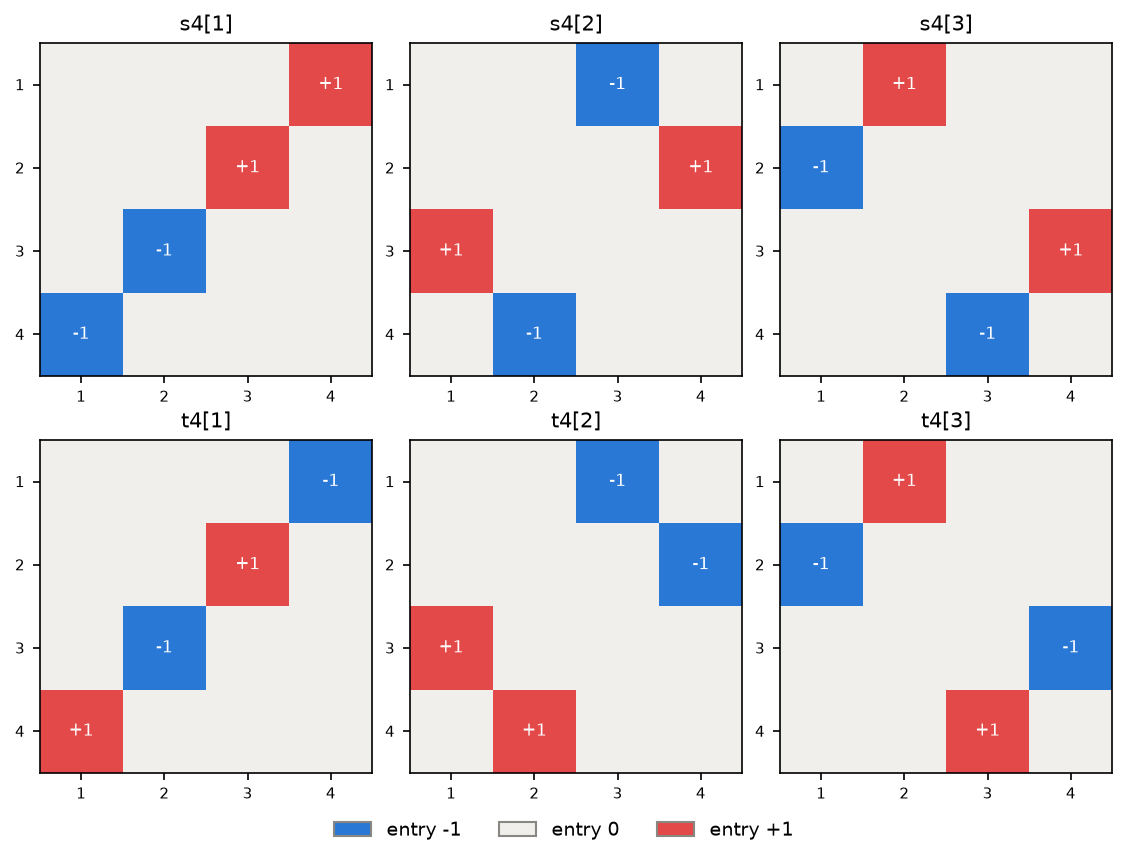

Figure 04a.1 saved as Revision/textbook/figures/04a_1_blocks_s4_t4.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(7.4, 5.6), layout="constrained")
for h in (1, 2, 3):
    draw_signs(axes[0, h - 1], s4[h], f"s4[{h}]", numbers=True, first=1)
    draw_signs(axes[1, h - 1], t4[h], f"t4[{h}]", numbers=True, first=1)
sign_legend(fig)
save_figure(fig, "blocks_s4_t4",
            "The six $4 \\times 4$ building blocks of the author: s4 for h = 1, 2, 3 "
            "(upper row) and t4 for h = 1, 2, 3 (lower row), computed from "
            "Signature and Kronecker deltas; rows and columns numbered 1 to 4 as in "
            "his formulas; blue $-1$, grey $0$, red $+1$. Every block has exactly "
            "one nonzero entry in each row and column and is antisymmetric: the "
            "square in row $p$, column $q$ has the opposite colour of the square in "
            "row $q$, column $p$.")

## 7. The rules of the blocks

The next cell checks four rules, for all h, k = 1, 2, 3:

1. every block is antisymmetric: $s4[h]^T = -s4[h]$ and $t4[h]^T = -t4[h]$;
2. every block squares to minus the identity: $s4[h]^2 = t4[h]^2 = -I_4$;
3. two different s-blocks anticommute, and so do two different t-blocks; together
   with rule 2 this is $\{s4[h], s4[k]\} = \{t4[h], t4[k]\} = -2\delta_{hk} I_4$;
4. every s-block commutes with every t-block: $s4[h]\,t4[k] = t4[k]\,s4[h]$.

Rules 2 and 3 are the rules of the imaginary units of the quaternions,
$\mathbf{i}^2 = \mathbf{j}^2 = \mathbf{k}^2 = -1$ and $\mathbf{ij} = -\mathbf{ji}$
(a later cell explains this). The Revision record checks them in both reports.

In [8]:
I4 = identity(4)
blocks = [s4[1], s4[2], s4[3], t4[1], t4[2], t4[3]]
antisymmetric = all((m.T == -m).all() for m in blocks)
square_minus_one = all((m @ m == -I4).all() for m in blocks)
anticommute = all((anticommutator(s4[h], s4[k]) == -2 * delta(h, k) * I4).all()
                  and (anticommutator(t4[h], t4[k]) == -2 * delta(h, k) * I4).all()
                  for h in (1, 2, 3) for k in (1, 2, 3))
s_t_commute = all((s4[h] @ t4[k] == t4[k] @ s4[h]).all()
                  for h in (1, 2, 3) for k in (1, 2, 3))
check_record(antisymmetric and square_minus_one and s_t_commute,
             "the blocks are antisymmetric, square to -I4, and s4 commutes with t4",
             (PYTHON, "blocks_antisymmetric_square_minus_one_commute"))
check_record(anticommute and s_t_commute and antisymmetric,
             "{s4[h], s4[k]} = {t4[h], t4[k]} = -2 delta_hk I4, [s4[h], t4[k]] = 0",
             (WOLFRAM, "s4_t4_quaternion_algebras"))

PASS the blocks are antisymmetric, square to -I4, and s4 commutes with t4
     reproduces Revision/algebra/reports/python-algebra.json
         check blocks_antisymmetric_square_minus_one_commute
PASS {s4[h], s4[k]} = {t4[h], t4[k]} = -2 delta_hk I4, [s4[h], t4[k]] = 0
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check s4_t4_quaternion_algebras


**Self-dual and anti-self-dual.** The author calls s4 *self-dual* and t4
*anti-self-dual*. The *dual* of a $4 \times 4$ matrix $M$ is the matrix
$(\star M)_{pq} = \tfrac12 \sum_{r,s} \epsilon_{pqrs} M_{rs}$, where the *Levi-Civita
symbol* $\epsilon_{pqrs}$ is the permutation sign of $(p, q, r, s)$. For an
antisymmetric $M$ only two terms survive in each sum, and they are equal; for example
$(\star M)_{12} = \tfrac12(\epsilon_{1234} M_{34} + \epsilon_{1243} M_{43})
= \tfrac12((+1) M_{34} + (-1)(-M_{34})) = M_{34}$, because exchanging the last two
numbers of (1, 2, 3, 4) flips the sign and $M_{43} = -M_{34}$. In the same way
$(\star M)_{13} = \epsilon_{1324} M_{24} = -M_{24}$ and
$(\star M)_{14} = \epsilon_{1423} M_{23} = M_{23}$. So $M$ is self-dual
($\star M = M$) when $M_{12} = M_{34}$, $M_{13} = -M_{24}$ and $M_{14} = M_{23}$.
For s4[1]: $M_{12} = 0 = M_{34}$, $M_{13} = 0 = -M_{24}$, $M_{14} = 1 = M_{23}$.

The next cell builds $\epsilon_{pqrs}$ for all 256 index lists (counting from 0 now;
the sign of a list does not depend on where the counting starts), computes the dual
of each block with numpy's `einsum` (which performs exactly the sum over $r$ and
$s$), and checks that every s4 is self-dual and every t4 anti-self-dual
($\star t4[h] = -t4[h]$).

In [9]:
epsilon = np.zeros((4, 4, 4, 4), dtype=np.int64)
for p, q, r, s in itertools.product(range(4), repeat=4):  # all 4^4 = 256 lists
    epsilon[p, q, r, s] = signature([p, q, r, s])


def dual(m):
    """(1/2) sum_rs epsilon_pqrs m_rs for every p, q (a 4 x 4 matrix)."""
    twice = np.einsum("pqrs,rs->pq", epsilon, m)  # the sum over r and s
    if (twice % 2).any():  # for an antisymmetric m every entry of twice is even
        raise ValueError("the dual is not a whole-number matrix")
    return twice // 2  # exact division by 2


for h in (1, 2, 3):
    say(f"h = {h}: dual(s4) == s4: {(dual(s4[h]) == s4[h]).all()},  "
        f"dual(t4) == -t4: {(dual(t4[h]) == -t4[h]).all()}")
check_record(all((dual(s4[h]) == s4[h]).all() and (dual(t4[h]) == -t4[h]).all()
                 for h in (1, 2, 3)),
             "every s4[h] is self-dual and every t4[h] anti-self-dual",
             (WOLFRAM, "s4_self_dual_t4_anti_self_dual"))

h = 1: dual(s4) == s4: True,  dual(t4) == -t4: True
h = 2: dual(s4) == s4: True,  dual(t4) == -t4: True
h = 3: dual(s4) == s4: True,  dual(t4) == -t4: True
PASS every s4[h] is self-dual and every t4[h] anti-self-dual
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check s4_self_dual_t4_anti_self_dual


**The blocks are quaternion multiplications.** A *quaternion* is
$q = q_4 + q_1\mathbf{i} + q_2\mathbf{j} + q_3\mathbf{k}$ with four real numbers; we
store it as the list $(q_1, q_2, q_3, q_4)$, real part last, to match the author's
blocks. Quaternions are multiplied with Hamilton's rules
$\mathbf{i}^2 = \mathbf{j}^2 = \mathbf{k}^2 = -1$,
$\mathbf{ij} = \mathbf{k} = -\mathbf{ji}$, $\mathbf{jk} = \mathbf{i} = -\mathbf{kj}$,
$\mathbf{ki} = \mathbf{j} = -\mathbf{ik}$; multiplying out $x\,y$ term by term with
these rules gives the four lines of `quaternion_product` below. For a fixed unit $u$
the maps $q \to q\,u$ (multiply on the right) and $q \to u\,q$ (multiply on the left)
are linear, so each is a $4 \times 4$ matrix: column $p$ of the matrix holds the
components of $e_p u$ (or $u e_p$), where $e_p$ is the quaternion with a 1 in
component $p$ and 0 elsewhere.

The next cell checks: s4[h] is the right multiplication by the unit
$\mathbf{i}, \mathbf{j}, \mathbf{k}$ (h = 1, 2, 3), and t4[h] is minus the left
multiplication by the same unit. This explains the rules above: the square of the
right multiplication by $\mathbf{i}$ is the right multiplication by
$\mathbf{i}^2 = -1$, which is $-I_4$; and multiplying on the left and on the right
can be done in either order, because $(u\,q)\,w = u\,(q\,w)$ for quaternions (their
multiplication is *associative*), which is why every s4 commutes with every t4.

In [10]:
def quaternion_product(x, y):
    """x y for quaternions stored as (q1, q2, q3, q4) = q4 + q1 i + q2 j + q3 k."""
    x1, x2, x3, x4 = x
    y1, y2, y3, y4 = y
    return (x4 * y1 + x1 * y4 + x2 * y3 - x3 * y2,  # the i component
            x4 * y2 + x2 * y4 + x3 * y1 - x1 * y3,  # the j component
            x4 * y3 + x3 * y4 + x1 * y2 - x2 * y1,  # the k component
            x4 * y4 - x1 * y1 - x2 * y2 - x3 * y3)  # the real component


UNITS = {1: (1, 0, 0, 0), 2: (0, 1, 0, 0), 3: (0, 0, 1, 0)}  # i, j, k
BASIS = [(1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0), (0, 0, 0, 1)]  # e_1, ..., e_4


def right_multiplication(u):
    """The 4 x 4 matrix of q -> q u: column p holds the components of e_p u."""
    return np.array([quaternion_product(e, u) for e in BASIS]).T


def left_multiplication(u):
    """The 4 x 4 matrix of q -> u q: column p holds the components of u e_p."""
    return np.array([quaternion_product(u, e) for e in BASIS]).T


say(f"i j = {quaternion_product(UNITS[1], UNITS[2])} (that is k), "
    f"j i = {quaternion_product(UNITS[2], UNITS[1])} (that is -k)")
check(quaternion_product(UNITS[1], UNITS[2]) == (0, 0, 1, 0)
      and quaternion_product(UNITS[1], UNITS[1]) == (0, 0, 0, -1),
      "the quaternion product follows Hamilton's rules i j = k and i i = -1")
check(all((s4[h] == right_multiplication(UNITS[h])).all()
          and (t4[h] == -left_multiplication(UNITS[h])).all() for h in (1, 2, 3)),
      "s4[h] is right and t4[h] minus left multiplication by i, j, k")

i j = (0, 0, 1, 0) (that is k), j i = (0, 0, -1, 0) (that is -k)
PASS the quaternion product follows Hamilton's rules i j = k and i i = -1
PASS s4[h] is right and t4[h] minus left multiplication by i, j, k


## 8. Step 2: sigma and the eight matrices tau[A]

The next cell builds the $8 \times 8$ matrices of the author's step 2 exactly as
the situation section states them: the frame metric eta4488 of his notebook, the
matrix sigma (it exchanges the upper four and the lower four components of a column
of eight), tau[0] = $I_8$, the three tau[h] made from s4[h], the three tau[7-h] made
from t4[h] (so tau[6] comes from t4[1], tau[5] from t4[2] and tau[4] from t4[3]),
tau[7] as the product of the first six, and taubar[A] = sigma tau[A]$^T$ sigma.
`np.block` glues blocks into a big matrix, row of blocks by row of blocks. Then it
prints the code of every row of tau[1], ..., tau[7] (the code +5 in row 2 means
$(\tau u)_2 = +u_5$; all tau are signed permutation matrices, which the function
`codes` confirms row by row).

In [11]:
I8, Z4, Z8 = identity(8), zeros(4), zeros(8)
eta4488 = np.diag([1, 1, 1, 1, -1, -1, -1, -1])  # In[45]: frame order A = 0..7
sigma = np.block([[Z4, I4], [I4, Z4]])  # In[46]
tau = {0: I8}  # In[338]
for h in (1, 2, 3):
    tau[h] = np.block([[Z4, s4[h]], [s4[h], Z4]])  # tau[1], tau[2], tau[3]
    tau[7 - h] = np.block([[Z4, t4[h]], [-t4[h], Z4]])  # tau[6], tau[5], tau[4]
tau[7] = tau[1] @ tau[2] @ tau[3] @ tau[4] @ tau[5] @ tau[6]  # In[338]
taubar = {0: I8}  # In[351]
for A in range(1, 8):
    taubar[A] = sigma @ tau[A].T @ sigma


def codes(m):
    """The code of every row of a signed permutation matrix m: "+5" in row i means
    (m u)_i = +u_5. Stops with an error if a row has not exactly one nonzero."""
    result = []
    for row in m:
        columns = np.flatnonzero(row)  # the columns of the nonzero entries
        if len(columns) != 1 or abs(row[columns[0]]) != 1:
            raise ValueError("not a signed permutation matrix")
        column = int(columns[0])
        result.append(("+" if row[column] > 0 else "-") + str(column))
    return result


labels = [f"tau[{A}]" for A in range(1, 8)]  # the column titles
print("row " + "".join(f"{label:>8}" for label in labels))
tau_codes = {A: codes(tau[A]) for A in range(1, 8)}
for i in range(8):
    print(f"{i:3d} " + "".join(f"{tau_codes[A][i]:>8}" for A in range(1, 8)))

row   tau[1]  tau[2]  tau[3]  tau[4]  tau[5]  tau[6]  tau[7]
  0       +7      -6      +5      +5      -6      -7      -0
  1       +6      +7      -4      -4      -7      +6      -1
  2       -5      +4      +7      -7      +4      -5      -2
  3       -4      -5      -6      +6      +5      +4      -3
  4       +3      -2      +1      -1      +2      +3      +4
  5       +2      +3      -0      +0      +3      -2      +5
  6       -1      +0      +3      +3      -0      +1      +6
  7       -0      -1      -2      -2      -1      -0      +7


The next cell draws the eight tau matrices as heat maps (rows and columns numbered
0 to 7).

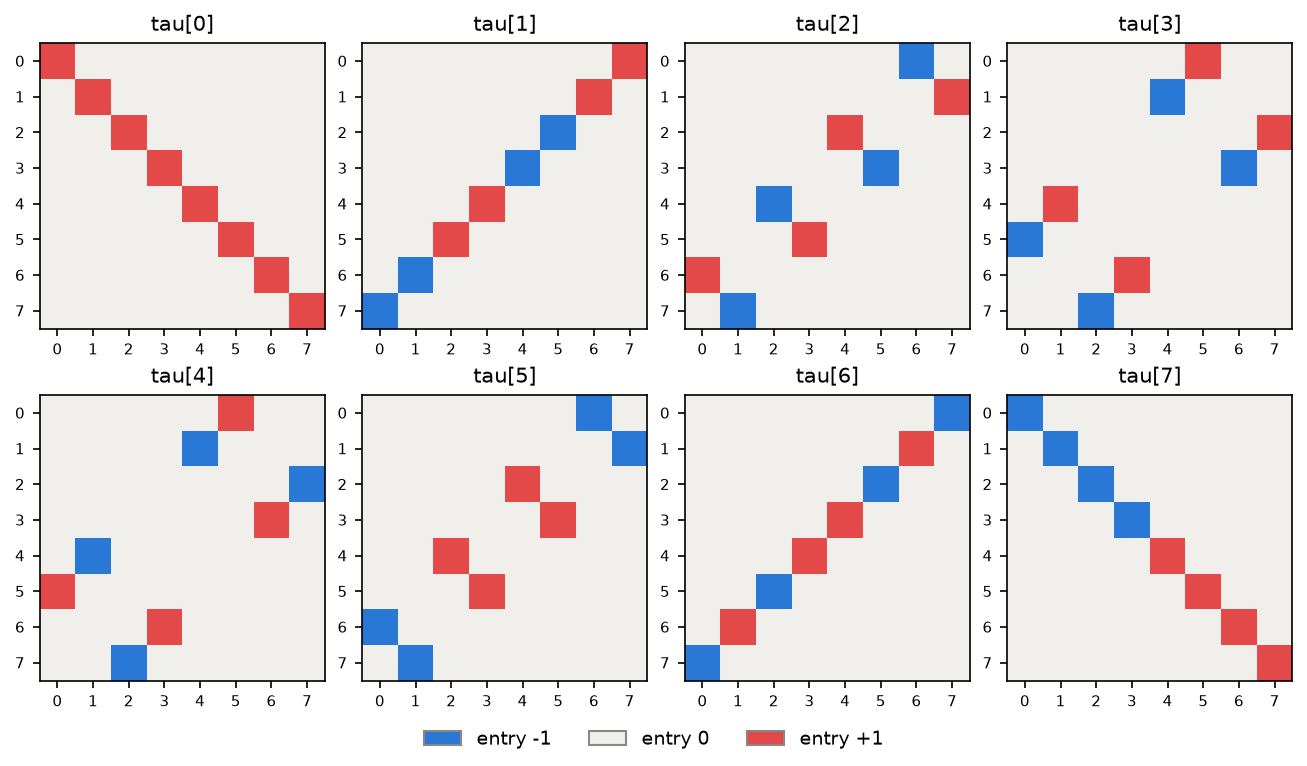

Figure 04a.2 saved as Revision/textbook/figures/04a_2_tau_matrices.png


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(8.6, 5.0), layout="constrained")
for A in range(8):
    draw_signs(axes[A // 4, A % 4], tau[A], f"tau[{A}]")  # // and %: row, column
sign_legend(fig)
save_figure(fig, "tau_matrices",
            "The author's eight $8 \\times 8$ matrices tau for A = 0 to 7 (rows and "
            "columns numbered 0 to 7; blue $-1$, grey $0$, red $+1$). tau 0 is the "
            "identity; tau 1 to tau 6 are made of two $4 \\times 4$ blocks in the "
            "upper-right and lower-left corners (s4 for A = 1, 2, 3 and t4 for "
            "A = 6, 5, 4); tau 7, the product of the first six, is diagonal with "
            "four entries $-1$ and four entries $+1$.")

## 9. The rules of sigma and tau

The next cell checks, exactly, everything that the Revision record checks about
these matrices:

- sigma is symmetric, has trace 0 (the sum of its diagonal entries) and
  $\sigma^2 = I_8$;
- tau[7] = diag(-1, -1, -1, -1, 1, 1, 1, 1) and tau[1] tau[2] ... tau[7] = $I_8$;
- sigma = tau[1] tau[2] tau[3] = tau[4] tau[5] tau[6] tau[7], and
  sigma taubar[A] = (sigma tau[A])$^T$ for A = 0, ..., 7;
- taubar[A] = -tau[A] for A = 1, ..., 7;
- tau[A] tau[B] + tau[B] tau[A] = $-2\,$eta4488$_{AB} I_8$ for A, B = 1, ..., 7: the
  seven matrices tau[1], ..., tau[7] satisfy a Clifford relation of their own (three
  square to $-I_8$, four to $+I_8$);
- tau[A] taubar[B] + tau[B] taubar[A] = taubar[A] tau[B] + taubar[B] tau[A] =
  $2\,$eta4488$_{AB} I_8$ for A, B = 0, ..., 7 (64 pairs). This is the key rule:
  the next step turns it into the Clifford relation of the $16 \times 16$ matrices.

In [13]:
sigma_ok = (sigma.T == sigma).all() and np.trace(sigma) == 0 \
    and (sigma @ sigma == I8).all()
check_record(sigma_ok, "sigma is symmetric, traceless and squares to I8",
             (WOLFRAM, "sigma8_involution"))

product_1_to_7 = I8
for A in range(1, 8):
    product_1_to_7 = product_1_to_7 @ tau[A]
check_record((tau[7] == np.diag([-1, -1, -1, -1, 1, 1, 1, 1])).all()
             and (product_1_to_7 == I8).all(),
             "tau[7] = diag(-I4, I4) and tau[1] tau[2] ... tau[7] = I8",
             (PYTHON, "tau7_and_product"))

sigma_products = (sigma == tau[1] @ tau[2] @ tau[3]).all() and \
    (sigma == tau[4] @ tau[5] @ tau[6] @ tau[7]).all()
sigma_transpose = all((sigma @ taubar[A] == (sigma @ tau[A]).T).all()
                      for A in range(8))
check_record(sigma_products and sigma_transpose,
             "sigma = tau1 tau2 tau3 = tau4 ... tau7 and sigma taubar = (sigma tau)^T",
             (WOLFRAM, "tau7_and_sigma_identities"),
             (PYTHON, "notebook_sigma_eq_tau1tau2tau3"))
check_record(sigma_transpose and all((taubar[A] == -tau[A]).all()
                                     for A in range(1, 8)),
             "taubar[A] = -tau[A] for A = 1, ..., 7",
             (PYTHON, "taubar_relations"))
check_record(all((anticommutator(tau[A], tau[B]) == -2 * eta4488[A, B] * I8).all()
                 for A in range(1, 8) for B in range(1, 8)),
             "tau[A] tau[B] + tau[B] tau[A] = -2 eta4488_AB I8 for A, B = 1..7",
             (PYTHON, "notebook_tau_clifford"))

PASS sigma is symmetric, traceless and squares to I8
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check sigma8_involution
PASS tau[7] = diag(-I4, I4) and tau[1] tau[2] ... tau[7] = I8
     reproduces Revision/algebra/reports/python-algebra.json
         check tau7_and_product
PASS sigma = tau1 tau2 tau3 = tau4 ... tau7 and sigma taubar = (sigma tau)^T
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check tau7_and_sigma_identities
     reproduces Revision/algebra/reports/python-algebra.json
         check notebook_sigma_eq_tau1tau2tau3
PASS taubar[A] = -tau[A] for A = 1, ..., 7
     reproduces Revision/algebra/reports/python-algebra.json
         check taubar_relations
PASS tau[A] tau[B] + tau[B] tau[A] = -2 eta4488_AB I8 for A, B = 1..7
     reproduces Revision/algebra/reports/python-algebra.json
         check notebook_tau_clifford


The last rule, for all 64 pairs (A, B). The next cell computes, for every pair, the
matrix tau[A] taubar[B] + tau[B] taubar[A], checks that it is a whole number times
$I_8$, prints these numbers as a table (row A, column B), and checks that the table is
twice eta4488. It does the same for the other order, taubar[A] tau[B] +
taubar[B] tau[A].

In [14]:
table = np.zeros((8, 8), dtype=np.int64)
multiples_of_identity = True
other_order = True
for A, B in itertools.product(range(8), repeat=2):  # all 64 pairs
    m = tau[A] @ taubar[B] + tau[B] @ taubar[A]
    table[A, B] = m[0, 0]  # the number that multiplies I8 (if it is a multiple)
    multiples_of_identity &= bool((m == table[A, B] * I8).all())
    other = taubar[A] @ tau[B] + taubar[B] @ tau[A]
    other_order &= bool((other == table[A, B] * I8).all())
print("A\\B" + "".join(f"{B:4d}" for B in range(8)))
for A in range(8):
    print(f"{A:3d}" + "".join(f"{table[A, B]:4d}" for B in range(8)))
check_record(multiples_of_identity and other_order and (table == 2 * eta4488).all(),
             "tau[A] taubar[B] + tau[B] taubar[A] = 2 eta4488_AB I8, both orders",
             (WOLFRAM, "tau_taubar_Clifford_relation"),
             (PYTHON, "notebook_tau_taubar_clifford"))

A\B   0   1   2   3   4   5   6   7
  0   2   0   0   0   0   0   0   0
  1   0   2   0   0   0   0   0   0
  2   0   0   2   0   0   0   0   0
  3   0   0   0   2   0   0   0   0
  4   0   0   0   0  -2   0   0   0
  5   0   0   0   0   0  -2   0   0
  6   0   0   0   0   0   0  -2   0
  7   0   0   0   0   0   0   0  -2
PASS tau[A] taubar[B] + tau[B] taubar[A] = 2 eta4488_AB I8, both orders
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check tau_taubar_Clifford_relation
     reproduces Revision/algebra/reports/python-algebra.json
         check notebook_tau_taubar_clifford


## 10. Step 3: the $16 \times 16$ matrices T16[A]

The author puts taubar[A] into the upper-right and tau[A] into the lower-left
$8 \times 8$ corner of a $16 \times 16$ matrix (In[371]), and multiplies the first
eight in order to obtain T16[8] (In[372]). Why this works: by the rule for
multiplying block matrices (blocks multiply like the entries of $2 \times 2$
matrices, keeping their order),

$$\mathrm{T16}[A]\,\mathrm{T16}[B] =
\begin{pmatrix} 0 & \bar\tau_A \\ \tau_A & 0 \end{pmatrix}
\begin{pmatrix} 0 & \bar\tau_B \\ \tau_B & 0 \end{pmatrix} =
\begin{pmatrix} \bar\tau_A \tau_B & 0 \\ 0 & \tau_A \bar\tau_B \end{pmatrix},$$

where $\bar\tau$ stands for taubar. Adding the same with A and B exchanged gives the
two diagonal blocks taubar[A] tau[B] + taubar[B] tau[A] and tau[A] taubar[B] +
tau[B] taubar[A], which the previous cell found to be $2\,$eta4488$_{AB} I_8$ each.
So T16[A] T16[B] + T16[B] T16[A] = $2\,$eta4488$_{AB} I_{16}$: the Clifford relation
in the author's frame order. The next cell builds the nine matrices and checks the
block form, and checks two facts about T16[8] that the Revision record states: it is
the diagonal matrix diag(-1, ..., -1, 1, ..., 1) with eight entries of each sign, and
T16[0] T16[1] ... T16[8] = $I_{16}$ (this is T16[8] T16[8] = $I_{16}$). The meaning of
T16[8] (it is called the *chirality*) belongs to the study of the matrices built from
the gammas; here it is only a product.

In [15]:
T16 = {A: np.block([[Z8, taubar[A]], [tau[A], Z8]]) for A in range(8)}  # In[371]
T16[8] = T16[0]
for A in range(1, 8):
    T16[8] = T16[8] @ T16[A]  # In[372]: T16[8] = T16[0] T16[1] ... T16[7]
I16 = identity(16)

# [:8, 8:] means rows 0 to 7 and columns 8 to 15 (the upper-right corner), etc.
block_form = all((T16[A][:8, :8] == 0).all() and (T16[A][8:, 8:] == 0).all()
                 and (T16[A][:8, 8:] == taubar[A]).all()
                 and (T16[A][8:, :8] == tau[A]).all() for A in range(8))
check_record(block_form, "T16[A] = ((0, taubar[A]), (tau[A], 0)) for A = 0, ..., 7",
             (WOLFRAM, "T16_block_form"))
say(f"diagonal of T16[8]: {list(int(x) for x in np.diag(T16[8]))}")
check_record((T16[8] == np.diag([-1] * 8 + [1] * 8)).all(),
             "T16[8] = T16[0] ... T16[7] = diag(-I8, I8)",
             (WOLFRAM, "Gamma_diag"), (PYTHON, "chirality_diag"))
product_0_to_8 = I16
for A in range(9):
    product_0_to_8 = product_0_to_8 @ T16[A]
check_record((product_0_to_8 == I16).all(), "T16[0] T16[1] ... T16[8] = I16",
             (WOLFRAM, "notebook_product_identity"))

PASS T16[A] = ((0, taubar[A]), (tau[A], 0)) for A = 0, ..., 7
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check T16_block_form
diagonal of T16[8]: [-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1]
PASS T16[8] = T16[0] ... T16[7] = diag(-I8, I8)
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check Gamma_diag
     reproduces Revision/algebra/reports/python-algebra.json
         check chirality_diag
PASS T16[0] T16[1] ... T16[8] = I16
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check notebook_product_identity


The next cell draws T16[4] (the matrix of the time direction $x_4$) and marks its
four $8 \times 8$ corners: the two zero blocks, taubar[4] (upper right) and tau[4]
(lower left). Rows and columns are numbered 0 to 15.

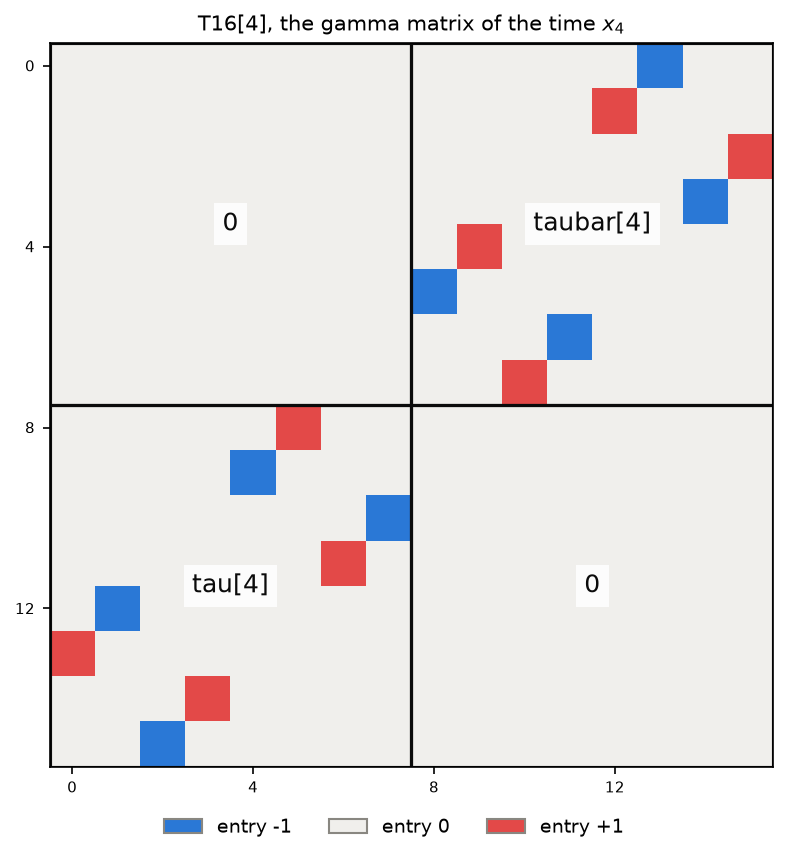

Figure 04a.3 saved as Revision/textbook/figures/04a_3_block_form_of_t16.png


In [16]:
fig, ax = plt.subplots(figsize=(5.6, 5.6), layout="constrained")
draw_signs(ax, T16[4], "T16[4], the gamma matrix of the time $x_4$")
for left, top in ((-0.5, -0.5), (7.5, -0.5), (-0.5, 7.5), (7.5, 7.5)):
    ax.add_patch(Rectangle((left, top), 8, 8, fill=False, edgecolor="#0b0b0b",
                           linewidth=1.5))  # the frame of one 8 x 8 corner
labels = {(3.5, 3.5): "0", (11.5, 3.5): "taubar[4]", (3.5, 11.5): "tau[4]",
          (11.5, 11.5): "0"}
for (x, y), label in labels.items():
    ax.text(x, y, label, ha="center", va="center", fontsize=12, color="#0b0b0b",
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})
sign_legend(fig)
save_figure(fig, "block_form_of_t16",
            "The $16 \\times 16$ matrix T16 4, the gamma matrix of the time "
            "direction $x_4$, with its four $8 \\times 8$ corners framed (rows and "
            "columns numbered 0 to 15; blue $-1$, grey $0$, red $+1$). The "
            "upper-left and lower-right corners are zero; the upper-right corner is "
            "taubar 4 and the lower-left corner is tau 4. Each of the sixteen rows "
            "holds exactly one nonzero entry.")

## 11. Step 4: the author's coordinates x1, ..., x8

The next cell renames the matrices after the author's coordinates. The list
`FRAME_INDEX` holds, for $x_1, \dots, x_8$ in this order, the index A of T16[A] in the
author's Mathematica notebook: 1, 2, 3, 4, 5, 6, 7, 0. The frame metric in the order
$x_1, \dots, x_8$ is read off from eta4488 through the same list. The cell prints one
line per coordinate and checks that $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1,
+1)$: space-like $x_1, x_2, x_3, x_8$ and time-like $x_4, x_5, x_6, x_7$, as the
author's metric requires. From here on, `gamma[0]` is $\gamma^{(x_1)}$, ...,
`gamma[7]` is $\gamma^{(x_8)}$ (a Python list counts from 0).

In [17]:
COORDINATES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
FRAME_INDEX = [1, 2, 3, 4, 5, 6, 7, 0]  # A of T16[A] for x1, ..., x8
ROLE = ["3-space", "3-space", "3-space", "the time", "extra time (deflating)",
        "extra time (deflating)", "extra time (deflating)", "hidden direction"]
gamma = [T16[A] for A in FRAME_INDEX]  # gamma[0] = gamma^(x1), ...
eta = np.array([eta4488[A, A] for A in FRAME_INDEX])  # signs in the order x1..x8
for a in range(8):
    kind = "space-like" if eta[a] > 0 else "time-like"
    print(f"gamma^({COORDINATES[a]}) = T16[{FRAME_INDEX[a]}]   eta = {eta[a]:+d}   "
          f"{kind:10}   {ROLE[a]}")
renamed = all(gamma[k - 1] is T16[k] for k in range(1, 8)) and gamma[7] is T16[0]
check_record(list(eta) == [1, 1, 1, -1, -1, -1, -1, 1] and renamed,
             "gamma^(xk) = T16[k], gamma^(x8) = T16[0], eta = diag(+,+,+,-,-,-,-,+)",
             (WOLFRAM, "coordinate_map"), (WOLFRAM, "eta_in_author_order"),
             (PYTHON, "coordinate_map"))

gamma^(x1) = T16[1]   eta = +1   space-like   3-space
gamma^(x2) = T16[2]   eta = +1   space-like   3-space
gamma^(x3) = T16[3]   eta = +1   space-like   3-space
gamma^(x4) = T16[4]   eta = -1   time-like    the time
gamma^(x5) = T16[5]   eta = -1   time-like    extra time (deflating)
gamma^(x6) = T16[6]   eta = -1   time-like    extra time (deflating)
gamma^(x7) = T16[7]   eta = -1   time-like    extra time (deflating)
gamma^(x8) = T16[0]   eta = +1   space-like   hidden direction
PASS gamma^(xk) = T16[k], gamma^(x8) = T16[0], eta = diag(+,+,+,-,-,-,-,+)
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check coordinate_map
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check eta_in_author_order
     reproduces Revision/algebra/reports/python-algebra.json
         check coordinate_map


The next cell prints all eight gamma matrices in the code notation: row $i$ of the
table gives, for each coordinate, the column and the sign of the single nonzero
entry in row $i$ of that gamma matrix. For example the first entry of the column
x1 is -15: $(\gamma^{(x_1)} u)_0 = -u_{15}$.

In [18]:
gamma_codes = [codes(g) for g in gamma]
print("row" + "".join(f"{name:>6}" for name in COORDINATES))
for i in range(16):
    print(f"{i:3d}" + "".join(f"{gamma_codes[a][i]:>6}" for a in range(8)))

row    x1    x2    x3    x4    x5    x6    x7    x8
  0   -15   +14   -13   -13   +14   +15    +8    +8
  1   -14   -15   +12   +12   +15   -14    +9    +9
  2   +13   -12   -15   +15   -12   +13   +10   +10
  3   +12   +13   +14   -14   -13   -12   +11   +11
  4   -11   +10    -9    +9   -10   -11   -12   +12
  5   -10   -11    +8    -8   -11   +10   -13   +13
  6    +9    -8   -11   -11    +8    -9   -14   +14
  7    +8    +9   +10   +10    +9    +8   -15   +15
  8    +7    -6    +5    +5    -6    -7    -0    +0
  9    +6    +7    -4    -4    -7    +6    -1    +1
 10    -5    +4    +7    -7    +4    -5    -2    +2
 11    -4    -5    -6    +6    +5    +4    -3    +3
 12    +3    -2    +1    -1    +2    +3    +4    +4
 13    +2    +3    -0    +0    +3    -2    +5    +5
 14    -1    +0    +3    +3    -0    +1    +6    +6
 15    -0    -1    -2    -2    -1    -0    +7    +7


The next cell draws the eight gamma matrices as heat maps.

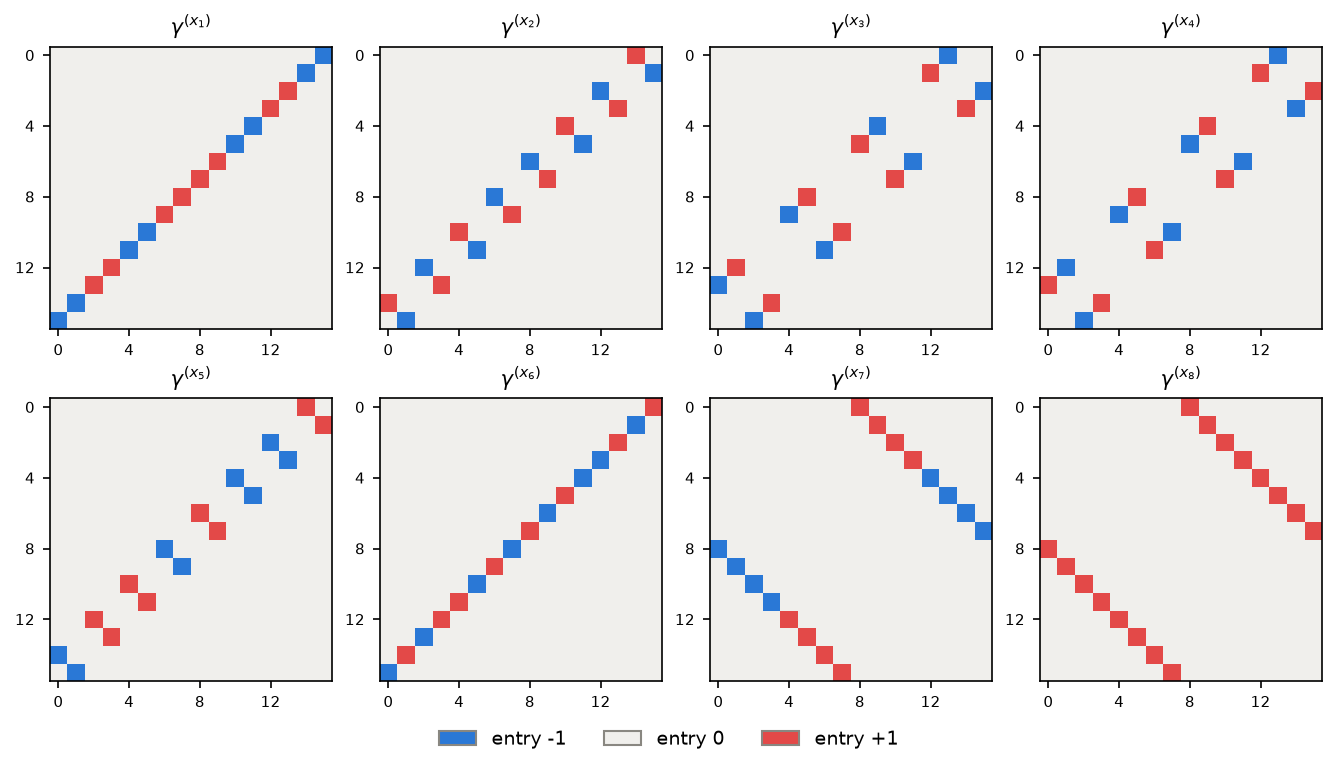

Figure 04a.4 saved as Revision/textbook/figures/04a_4_gammas_x1_to_x8.png


In [19]:
fig, axes = plt.subplots(2, 4, figsize=(8.8, 5.0), layout="constrained")
for a in range(8):
    draw_signs(axes[a // 4, a % 4], gamma[a], f"$\\gamma^{{(x_{a + 1})}}$")
sign_legend(fig)
save_figure(fig, "gammas_x1_to_x8",
            "The author's eight real $16 \\times 16$ gamma matrices in the order of "
            "his coordinates: 3-space $x_1, x_2, x_3$, the time $x_4$, the "
            "deflating extra times $x_5, x_6, x_7$ (lower row, first three) and the "
            "hidden direction $x_8$ (rows and columns numbered 0 to 15; blue $-1$, "
            "grey $0$, red $+1$). Every matrix has exactly one nonzero entry in each "
            "row and column, all of them in the upper-right and lower-left "
            "$8 \\times 8$ corners; $\\gamma^{(x_8)}$ simply exchanges the upper and "
            "the lower eight components.")

## 12. The Clifford relation for all 64 pairs

The next cell computes the anticommutator $\gamma^a\gamma^b + \gamma^b\gamma^a$ for
all 64 ordered pairs $(a, b)$ of coordinates, checks that each one is a whole number
times $I_{16}$, prints these numbers as a table (row $a$, column $b$), and checks that
the table is $2\eta$: 2 on the diagonal for $x_1, x_2, x_3, x_8$, $-2$ on the diagonal
for $x_4, \dots, x_7$, and 0 off the diagonal. It also checks that the squares
$(\gamma^a)^2$, written as the record writes them ("x1:1, x2:1, ..."), appear word
for word in the detail text of the WolframScript check.

In [20]:
c = np.zeros((8, 8), dtype=np.int64)  # {gamma^a, gamma^b} = c[a, b] I16
all_multiples = True
for a, b in itertools.product(range(8), repeat=2):
    m = anticommutator(gamma[a], gamma[b])
    c[a, b] = m[0, 0]
    all_multiples &= bool((m == c[a, b] * I16).all())
print("a\\b" + "".join(f"{name:>5}" for name in COORDINATES))
for a in range(8):
    print(f"{COORDINATES[a]:>3}" + "".join(f"{c[a, b]:5d}" for b in range(8)))
squares = ", ".join(f"{COORDINATES[a]}:{c[a, a] // 2}" for a in range(8))
say(f"squares (gamma^a)^2 / I16: {squares}")
recorded = RECORDED[WOLFRAM]["Clifford_relation"]["detail"]
check_record(all_multiples and (c == 2 * np.diag(eta)).all() and squares in recorded,
             "{gamma^a, gamma^b} = 2 eta^ab I16 for all 64 pairs a, b",
             (WOLFRAM, "Clifford_relation"), (PYTHON, "clifford_relation"))

a\b   x1   x2   x3   x4   x5   x6   x7   x8
 x1    2    0    0    0    0    0    0    0
 x2    0    2    0    0    0    0    0    0
 x3    0    0    2    0    0    0    0    0
 x4    0    0    0   -2    0    0    0    0
 x5    0    0    0    0   -2    0    0    0
 x6    0    0    0    0    0   -2    0    0
 x7    0    0    0    0    0    0   -2    0
 x8    0    0    0    0    0    0    0    2
squares (gamma^a)^2 / I16: x1:1, x2:1, x3:1, x4:-1, x5:-1, x6:-1, x7:-1, x8:1
PASS {gamma^a, gamma^b} = 2 eta^ab I16 for all 64 pairs a, b
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check Clifford_relation
     reproduces Revision/algebra/reports/python-algebra.json
         check clifford_relation


The next cell repeats the 36 different relations (pairs with $a \le b$; the others
follow because $\{\gamma^a,\gamma^b\} = \{\gamma^b,\gamma^a\}$) with sympy, a second
program that knows nothing of numpy, exactly as the Revision Python checker did with
its second engine.

In [21]:
sympy_gamma = [sp.Matrix(g.tolist()) for g in gamma]  # the same entries, in sympy
sympy_ok = all(
    sympy_gamma[a] * sympy_gamma[b] + sympy_gamma[b] * sympy_gamma[a]
    == 2 * int(eta[a] * delta(a, b)) * sp.eye(16)
    for a in range(8) for b in range(a, 8))
check_record(sympy_ok, "sympy confirms the 36 relations {gamma^a, gamma^b} = 2 eta^ab",
             (PYTHON, "clifford_relation_sympy"))

PASS sympy confirms the 36 relations {gamma^a, gamma^b} = 2 eta^ab
     reproduces Revision/algebra/reports/python-algebra.json
         check clifford_relation_sympy


**One relation followed by hand.** With the codes one can check a row of a
relation without a computer. The next cell does it the way a student would with
pencil and paper, for row 0, and prints every step:

- $(\gamma^{(x_4)})^2 = -I_{16}$: row 0 of $\gamma^{(x_4)}$ says
  $(\gamma^{(x_4)} v)_0 = s_1 v_{c_1}$; with $v = \gamma^{(x_4)} u$, row $c_1$ says
  $v_{c_1} = s_2 u_{c_2}$; so $(\gamma^{(x_4)}\gamma^{(x_4)} u)_0 = s_1 s_2 u_{c_2}$,
  which must be $-u_0$;
- $\gamma^{(x_8)}\gamma^{(x_4)} = -\gamma^{(x_4)}\gamma^{(x_8)}$: the two orders
  must give row 0 with the same column and opposite signs.

In [22]:
def follow(m, row):
    """(m u)_row = sign * u_column for a signed permutation m: return (sign, column)."""
    column = int(np.flatnonzero(m[row])[0])
    return int(m[row, column]), column


def signed(sign, letter, index):
    """The text "+u_5" or "-u_5" for sign = +1 or -1, letter = "u", index = 5."""
    return ("+" if sign > 0 else "-") + letter + "_" + str(index)


g4, g8 = gamma[3], gamma[7]  # gamma^(x4) and gamma^(x8)
s1, c1 = follow(g4, 0)  # row 0 of gamma^(x4)
s2, c2 = follow(g4, c1)  # row c1 of gamma^(x4)
say(f"row 0 of gamma^(x4):  (gamma^(x4) v)_0 = {signed(s1, "v", c1)}")
say(f"row {c1} of gamma^(x4): (gamma^(x4) u)_{c1} = {signed(s2, "u", c2)}")
say(f"with v = gamma^(x4) u: (gamma^(x4) gamma^(x4) u)_0 = {signed(s1 * s2, "u", c2)}")
t1, d1 = follow(g8, 0)  # row 0 of gamma^(x8) gamma^(x4): first gamma^(x8) ...
t2, d2 = follow(g4, d1)  # ... then row d1 of gamma^(x4)
r1, e1 = follow(g4, 0)  # row 0 of gamma^(x4) gamma^(x8): first gamma^(x4) ...
r2, e2 = follow(g8, e1)  # ... then row e1 of gamma^(x8)
say(f"(gamma^(x8) gamma^(x4) u)_0 = {signed(t1 * t2, "u", d2)};  "
    f"(gamma^(x4) gamma^(x8) u)_0 = {signed(r1 * r2, "u", e2)}")
check(s1 * s2 == -1 and c2 == 0, "by hand: row 0 of (gamma^(x4))^2 is -u_0")
check(d2 == e2 and t1 * t2 == -(r1 * r2),
      "by hand: row 0 of gamma^(x8) gamma^(x4) is minus that of gamma^(x4) gamma^(x8)")

row 0 of gamma^(x4):  (gamma^(x4) v)_0 = -v_13
row 13 of gamma^(x4): (gamma^(x4) u)_13 = +u_0
with v = gamma^(x4) u: (gamma^(x4) gamma^(x4) u)_0 = -u_0
(gamma^(x8) gamma^(x4) u)_0 = +u_5;  (gamma^(x4) gamma^(x8) u)_0 = -u_5
PASS by hand: row 0 of (gamma^(x4))^2 is -u_0
PASS by hand: row 0 of gamma^(x8) gamma^(x4) is minus that of gamma^(x4) gamma^(x8)


The next cell draws the table of the numbers $c_{ab}$ in
$\{\gamma^a,\gamma^b\} = c_{ab} I_{16}$ as a heat map, with each number written into
its square.

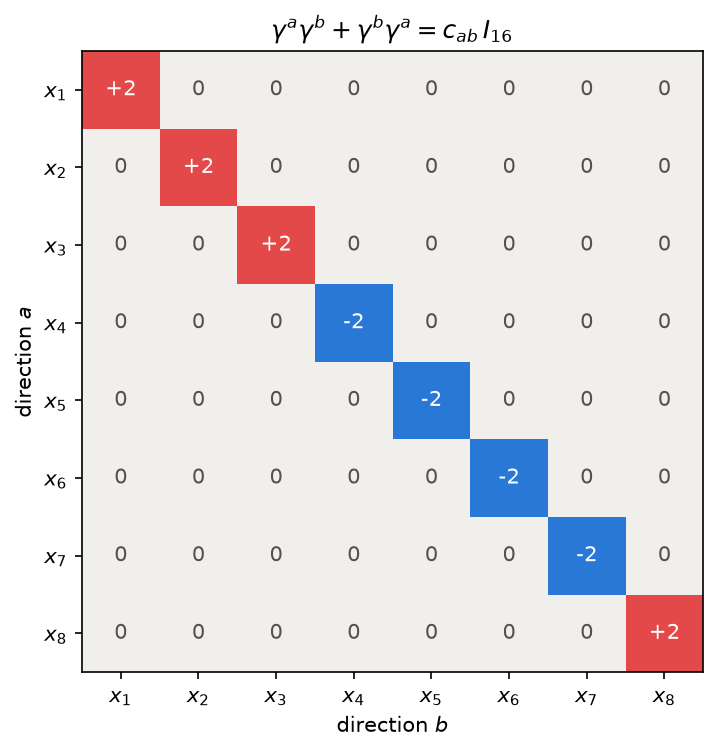

Figure 04a.5 saved as Revision/textbook/figures/04a_5_anticommutator_table.png


In [23]:
fig, ax = plt.subplots(figsize=(5.4, 4.9), layout="constrained")
colours = ListedColormap(["#2a78d6", "#f0efec", "#e34948"])  # -2, 0, +2
ax.imshow(c, cmap=colours, norm=BoundaryNorm([-3, -1, 1, 3], 3))
for (a, b), value in np.ndenumerate(c):
    ax.text(b, a, f"{value:+d}" if value else "0", ha="center", va="center",
            color="white" if value else "#52514e", fontsize=10)
labels = [f"$x_{k}$" for k in range(1, 9)]
ax.set_xticks(range(8), labels)
ax.set_yticks(range(8), labels)
ax.set_xlabel("direction $b$")
ax.set_ylabel("direction $a$")
ax.set_title("$\\gamma^a\\gamma^b + \\gamma^b\\gamma^a = c_{ab}\\, I_{16}$")
ax.grid(False)
save_figure(fig, "anticommutator_table",
            "The Clifford relation of the author's gammas: the number $c_{ab}$ in "
            "$\\gamma^a\\gamma^b + \\gamma^b\\gamma^a = c_{ab} I_{16}$ for all 64 "
            "pairs of directions, row $a$ and column $b$ running over $x_1$ to "
            "$x_8$ (red $+2$, blue $-2$, grey $0$). The table is $2\\eta$: $+2$ on "
            "the diagonal for the space-like directions $x_1, x_2, x_3, x_8$, $-2$ "
            "for the time-like directions $x_4$ to $x_7$, and $0$ off the diagonal, "
            "because two different gamma matrices anticommute.")

## 13. Reality, signed permutations, symmetry

The next cell checks three more properties that the Revision record checks:

1. **reality**: every entry is $-1$, $0$ or $+1$ (in particular real);
2. every $\gamma^a$ is a **signed permutation matrix** (one nonzero entry in each row
   and in each column); such a matrix is *orthogonal*: $M^T M = I$;
3. the **symmetry pattern**: $\gamma^a$ is symmetric for the space-like directions
   $x_1, x_2, x_3, x_8$ and antisymmetric for the time-like directions
   $x_4, \dots, x_7$; in one formula $(\gamma^a)^T = \eta_{aa}\gamma^a$.

Point 3 follows from point 2 and the Clifford relation, line by line:
$(\gamma^a)^T = (\gamma^a)^{-1}$ (orthogonal); $(\gamma^a)^2 = \eta_{aa} I_{16}$
(Clifford relation with $b = a$), so $\gamma^a \cdot \eta_{aa}\gamma^a = I_{16}$
(multiply by $\eta_{aa}$ and use $\eta_{aa}^2 = 1$), that is
$(\gamma^a)^{-1} = \eta_{aa}\gamma^a$; together, $(\gamma^a)^T = \eta_{aa}\gamma^a$.

In [24]:
entries = sorted(set(int(x) for g in gamma for x in g.flatten()))
say(f"the different entries of the eight gamma matrices: {entries}")
rows_ok = all((np.count_nonzero(g, axis=1) == 1).all() for g in gamma)  # each row
columns_ok = all((np.count_nonzero(g, axis=0) == 1).all() for g in gamma)  # column
orthogonal = all((g.T @ g == I16).all() for g in gamma)
check_record(entries == [-1, 0, 1], "every gamma^a is real with entries -1, 0, +1",
             (WOLFRAM, "reality"))
check_record(rows_ok and columns_ok and orthogonal,
             "every gamma^a is a signed permutation matrix, hence orthogonal",
             (WOLFRAM, "signed_permutation_matrices"),
             (PYTHON, "reality_signed_permutations"))
symmetric = [COORDINATES[a] for a in range(8) if (gamma[a].T == gamma[a]).all()]
antisymmetric = [COORDINATES[a] for a in range(8) if (gamma[a].T == -gamma[a]).all()]
say("symmetric: " + ", ".join(symmetric) + ";  antisymmetric: "
    + ", ".join(antisymmetric))
check_record(symmetric == ["x1", "x2", "x3", "x8"]
             and antisymmetric == ["x4", "x5", "x6", "x7"]
             and all((gamma[a].T == eta[a] * gamma[a]).all() for a in range(8)),
             "(gamma^a)^T = eta_aa gamma^a: symmetric for x1, x2, x3, x8 only",
             (WOLFRAM, "symmetry_pattern"), (PYTHON, "symmetry_pattern"))

the different entries of the eight gamma matrices: [-1, 0, 1]
PASS every gamma^a is real with entries -1, 0, +1
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check reality
PASS every gamma^a is a signed permutation matrix, hence orthogonal
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check signed_permutation_matrices
     reproduces Revision/algebra/reports/python-algebra.json
         check reality_signed_permutations
symmetric: x1, x2, x3, x8;  antisymmetric: x4, x5, x6, x7
PASS (gamma^a)^T = eta_aa gamma^a: symmetric for x1, x2, x3, x8 only
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check symmetry_pattern
     reproduces Revision/algebra/reports/python-algebra.json
         check symmetry_pattern


The next cell shows the symmetry pattern in a picture: $\gamma^{(x_1)}$ next to its
transpose (the same picture: symmetric) and $\gamma^{(x_4)}$ next to its transpose
(every colour flipped: antisymmetric).

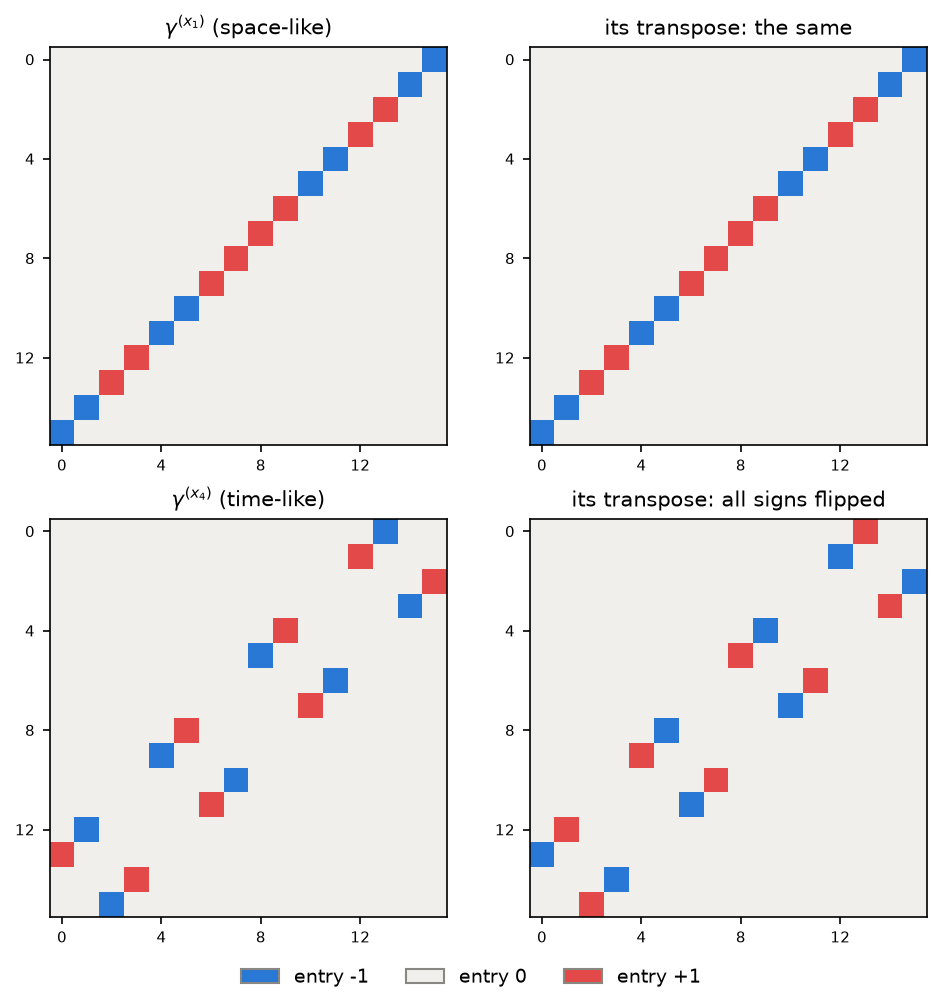

Figure 04a.6 saved as Revision/textbook/figures/04a_6_symmetry_pattern.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(6.4, 6.6), layout="constrained")
draw_signs(axes[0, 0], gamma[0], "$\\gamma^{(x_1)}$ (space-like)")
draw_signs(axes[0, 1], gamma[0].T, "its transpose: the same")
draw_signs(axes[1, 0], gamma[3], "$\\gamma^{(x_4)}$ (time-like)")
draw_signs(axes[1, 1], gamma[3].T, "its transpose: all signs flipped")
sign_legend(fig)
save_figure(fig, "symmetry_pattern",
            "The symmetry pattern of the gammas (rows and columns numbered 0 to 15; "
            "blue $-1$, grey $0$, red $+1$). Upper row: the space-like "
            "$\\gamma^{(x_1)}$ and its transpose (rows and columns exchanged) are "
            "the same picture, so $\\gamma^{(x_1)}$ is symmetric. Lower row: the "
            "transpose of the time-like $\\gamma^{(x_4)}$ has every colour flipped, "
            "so $\\gamma^{(x_4)}$ is antisymmetric. In general "
            "$(\\gamma^a)^T = \\eta_{aa}\\gamma^a$.")

## 14. Comparison with the Revision record files

The Revision record stores the eight gammas in two files:
`Revision/algebra/gammas.json` (written by the WolframScript verifier) and
`Revision/algebra/reports/python-gammas.json` (written by the Python checker). In
`gammas.json` every number is written exactly: a whole number as a JSON integer and a
fraction as a text "p/q" (the function `exact` below reads both). The next cell reads
both files, compares the coordinate names, the frame metric, the map to the author's
index A, and every one of the $8 \times 256 = 2048$ entries of the gammas with the
matrices built above, and counts the entries that differ.

In [26]:
def exact(entry):
    """An exact number of gammas.json: a JSON integer, or a text "p/q"."""
    if isinstance(entry, int):
        return Fraction(entry)
    if isinstance(entry, str) and "/" in entry:
        numerator, denominator = entry.split("/")
        return Fraction(int(numerator), int(denominator))
    raise ValueError(f"an entry of gammas.json that is not exact: {entry}")


def differing(stored, ours):
    """How many entries of the stored matrix differ from our integer matrix."""
    return sum(1 for (i, j), x in np.ndenumerate(ours)
               if exact(stored[i][j]) != int(x))


fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
python_gammas = json.loads(repository_file(
    "Revision/algebra/reports/python-gammas.json").read_text(encoding="utf-8"))
fixture_differ = [differing(fixture["gamma"][a], gamma[a]) for a in range(8)]
python_differ = [differing(python_gammas["gamma"][a], gamma[a]) for a in range(8)]
report("entries compared per file", 8 * 16 * 16)
report("differing entries, gammas.json, per x1..x8", fixture_differ)
report("differing entries, python-gammas.json, per x1..x8", python_differ)
check_record(fixture["coordinates"] == COORDINATES and fixture["eta"] == list(eta)
             and fixture["notebookFrameIndex"] == FRAME_INDEX
             and sum(fixture_differ) == 0,
             "Revision/algebra/gammas.json holds exactly these eight gammas",
             (WOLFRAM, "fixture_round_trip"),
             (PYTHON, "fixture_comparison_gammas_json"))
python_map = python_gammas["map_coordinate_to_T16_index"]  # {"x1": 1, ...}
check(python_map == dict(zip(COORDINATES, FRAME_INDEX)) and sum(python_differ) == 0,
      "Revision/algebra/reports/python-gammas.json holds exactly these eight gammas")

RESULT entries compared per file = 2048
RESULT differing entries, gammas.json, per x1..x8 = [0, 0, 0, 0, 0, 0, 0, 0]
RESULT differing entries, python-gammas.json, per x1..x8 = [0, 0, 0, 0, 0, 0, 0, 0]
PASS Revision/algebra/gammas.json holds exactly these eight gammas
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check fixture_round_trip
     reproduces Revision/algebra/reports/python-algebra.json
         check fixture_comparison_gammas_json
PASS Revision/algebra/reports/python-gammas.json holds exactly these eight gammas


The next cell prints the totals of the two Revision reports and how many different
Revision checks this notebook has reproduced.

In [27]:
for report_file in (WOLFRAM, PYTHON):
    verdicts = [entry["verdict"].upper() for entry in RECORDED[report_file].values()]
    passed = verdicts.count("PASS")  # how many checks of the report passed
    mine = [name for f, name in REPRODUCED if f == report_file]
    report(f"{report_file} passed", f"{passed} of {len(verdicts)}")
    report("    of these checks, reproduced in this notebook", len(mine))
check(len(REPRODUCED) == 30, "this notebook reproduces 30 checks of the two reports")

RESULT Revision/algebra/reports/wolfram-algebra.json passed = 45 of 45
RESULT     of these checks, reproduced in this notebook = 16
RESULT Revision/algebra/reports/python-algebra.json passed = 35 of 35
RESULT     of these checks, reproduced in this notebook = 14
PASS this notebook reproduces 30 checks of the two reports


## 15. The last check

The last cell checks that the six figure files exist in the folder
`Revision/textbook/figures` and prints the number of checks that passed.

In [28]:
names = ["04a_1_blocks_s4_t4.png", "04a_2_tau_matrices.png",
         "04a_3_block_form_of_t16.png", "04a_4_gammas_x1_to_x8.png",
         "04a_5_anticommutator_table.png", "04a_6_symmetry_pattern.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in names),
      "all six figure files exist")
all_checks_passed()

PASS all six figure files exist
ALL 28 CHECKS PASSED (notebook 04a)


## 16. What this notebook showed

- PROVED (exact integer arithmetic, this notebook; also in the Revision reports
  `Revision/algebra/reports/wolfram-algebra.json` and `python-algebra.json`): the
  author's formulas give six $4 \times 4$ blocks, exactly the ones his notebook
  displays; they are antisymmetric, square to $-I_4$, s4 is self-dual and t4
  anti-self-dual, and every s4 commutes with every t4. The blocks are the right
  (s4) and minus the left (t4) multiplications by the quaternion units
  $\mathbf{i}, \mathbf{j}, \mathbf{k}$, which explains these rules.
- PROVED: the $8 \times 8$ matrices satisfy sigma = tau[1] tau[2] tau[3] =
  tau[4] tau[5] tau[6] tau[7], tau[7] = diag(-I4, I4), taubar[A] = -tau[A]
  (A = 1, ..., 7), and the key rule tau[A] taubar[B] + tau[B] taubar[A] =
  $2\,$eta4488$_{AB} I_8$ for all 64 pairs.
- PROVED: the $16 \times 16$ matrices T16[A] = ((0, taubar[A]), (tau[A], 0)) satisfy
  the Clifford relation; renamed after the author's coordinates
  ($\gamma^{(x_8)}$ = T16[0], $\gamma^{(x_k)}$ = T16[k] for k = 1, ..., 7) they
  satisfy $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab} I_{16}$ with
  $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ for all 64 pairs (numpy and
  sympy); they are real signed permutation matrices, symmetric for $x_1, x_2, x_3,
  x_8$ and antisymmetric for the time $x_4$ and the deflating extra times
  $x_5, x_6, x_7$.
- The matrices agree entry by entry with the Revision record files
  `Revision/algebra/gammas.json` and `Revision/algebra/reports/python-gammas.json`;
  the notebook reproduces 30 checks of the two Revision reports.
- ASSUMED: nothing beyond the author's formulas. The gamma matrices are pure
  algebra: they make no physical claim. They are constant; the inflation of 3-space
  and the deflation of the extra times enter only later, through the frame factors
  of the metric.